# 4. Credit Risk Analysis

Credit Risk Analysis is performed to understand the factors and borrower segments associated with loan default within the dataset.

The objective is to transform the cleaned data into actionable risk insights by analyzing:

- Overall loan default rate
- Default rate across loan grades
- Default rate across loan purposes
- Default rate across home ownership categories
- Default rate across previous default history
- Income and loan burden
- Interest rate and default patterns
- Loan-to-income risk
- High-risk borrower segments
- Potential anomalous observations

The analysis identifies statistical patterns in the dataset that can support credit-risk monitoring and subsequent predictive modeling.

### 4.1 Load the Cleaned Dataset

The cleaned dataset generated during the Data Cleaning stage is loaded for credit risk analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("credit_risk_cleaned.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 4.2 Overall Loan Default Rate

The overall default rate represents the percentage of loans in the dataset with a default outcome.

This provides a baseline against which different borrower and loan segments can be compared.

In [3]:
total_loans = len(df)
total_defaults = df["loan_status"].sum()
default_rate = (total_defaults / total_loans) * 100
print("Total Loans:", total_loans)
print("Total Defaults:", total_defaults)
print("Overall Default Rate:", round(default_rate, 2), "%")

Total Loans: 32416
Total Defaults: 7089
Overall Default Rate: 21.87 %


### 4.3 Default and Non-Default Distribution

The number of default and non-default loans is analyzed to understand the target distribution.

This is particularly important before machine learning because an imbalanced target can influence model evaluation and the choice of performance metrics.

In [4]:
status_counts = df["loan_status"].value_counts()
status_counts.index = ["Non-Default" if x == 0 else "Default" for x in status_counts.index]
status_counts

,count
Non-Default,25327
Default,7089


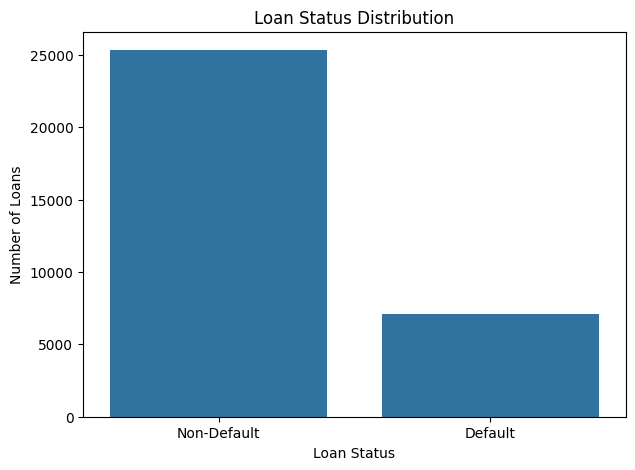

In [5]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.show()

### 4.4 Default Rate by Loan Grade

Loan grade is an important risk-related categorical variable.

The observed default rate is calculated for each loan grade to determine whether default rates vary across the grading categories.

In [6]:
grade_risk = (
    df.groupby("loan_grade")
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)
grade_risk["Default_Rate"] = (grade_risk["Default_Rate"] * 100).round(2)
grade_risk

,Total_Loans,Defaults,Default_Rate
loan_grade,,,
A,10703,1066,9.96
B,10387,1695,16.32
C,6438,1336,20.75
D,3620,2138,59.06
E,963,621,64.49
F,241,170,70.54
G,64,63,98.44


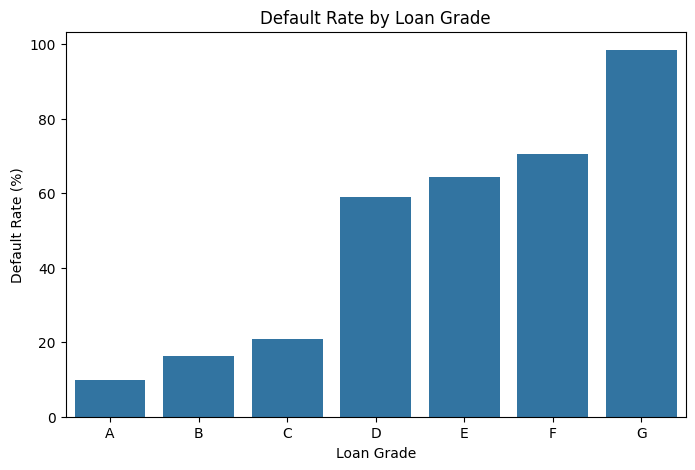

In [7]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=grade_risk.index,
    y=grade_risk["Default_Rate"]
)
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")
plt.show()

### 4.5 Default Rate by Loan Purpose

Different loan purposes may exhibit different observed default rates.

The default rate is calculated across loan-intent categories to identify segments requiring further investigation.

In [8]:
intent_risk = (
    df.groupby("loan_intent")
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)
intent_risk["Default_Rate"] = (intent_risk["Default_Rate"] * 100).round(2)
intent_risk.sort_values("Default_Rate",ascending=False)

,Total_Loans,Defaults,Default_Rate
loan_intent,,,
DEBTCONSOLIDATION,5189,1488,28.68
MEDICAL,6042,1617,26.76
HOMEIMPROVEMENT,3594,940,26.15
PERSONAL,5498,1094,19.90
EDUCATION,6411,1106,17.25
VENTURE,5682,844,14.85


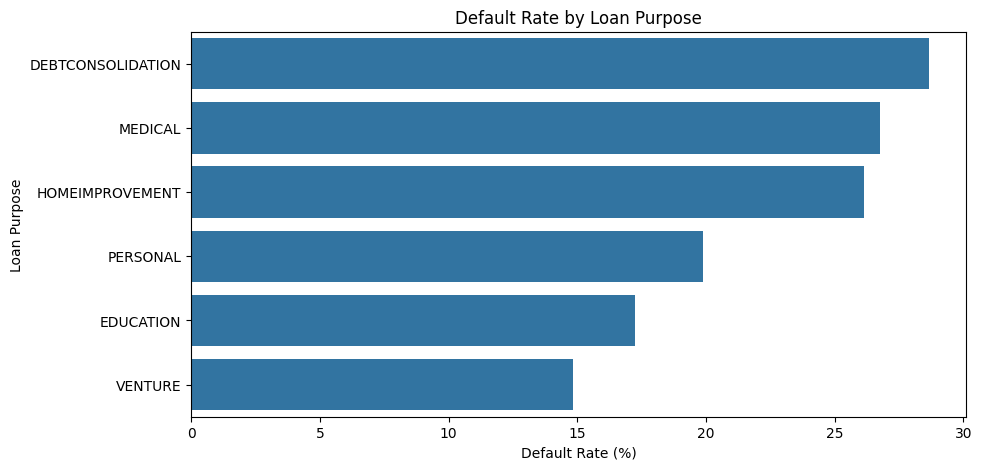

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=intent_risk.sort_values("Default_Rate", ascending=False),
    x="Default_Rate",
    y=intent_risk.sort_values("Default_Rate", ascending=False).index
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

plt.show()

### 4.6 Default Rate by Home Ownership

Borrower home ownership status is analyzed to determine whether observed default rates differ across ownership categories.

In [10]:
home_risk = (
    df.groupby("person_home_ownership")
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)
home_risk["Default_Rate"] = (home_risk["Default_Rate"] * 100).round(2)
home_risk.sort_values("Default_Rate",ascending=False)

,Total_Loans,Defaults,Default_Rate
person_home_ownership,,,
RENT,16378,5177,31.61
OTHER,106,33,31.13
MORTGAGE,13369,1687,12.62
OWN,2563,192,7.49


### 4.7 Previous Default History Analysis

Previous default history is analyzed to examine whether applicants with a recorded historical default show different current loan outcomes.

This variable can provide useful information for understanding borrower credit behavior.

In [11]:
previous_default_risk = (
    df.groupby("cb_person_default_on_file")
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)
previous_default_risk["Default_Rate"] = (previous_default_risk["Default_Rate"] * 100).round(2)
previous_default_risk

,Total_Loans,Defaults,Default_Rate
cb_person_default_on_file,,,
N,26686,4919,18.43
Y,5730,2170,37.87


### 4.8 Income-Based Risk Segmentation

Applicants are divided into income segments using quartiles.

This allows default rates to be compared across relatively lower- and higher-income borrower groups without imposing arbitrary income thresholds.

In [12]:
df["income_segment"] = pd.qcut(
    df["person_income"],
    q=4,
    labels=[
        "Low Income",
        "Lower-Middle Income",
        "Upper-Middle Income",
        "High Income"
    ]
)
income_risk = (
    df.groupby("income_segment", observed=True)
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)
income_risk["Default_Rate"] = (income_risk["Default_Rate"] * 100).round(2)
income_risk

,Total_Loans,Defaults,Default_Rate
income_segment,,,
Low Income,8104,3221,39.75
Lower-Middle Income,8188,1753,21.41
Upper-Middle Income,8020,1375,17.14
High Income,8104,740,9.13


### 4.9 Loan-to-Income Risk Segmentation

The loan-to-income ratio represents the requested loan amount relative to the applicant's income.

Applicants are grouped into quartiles based on this ratio to investigate whether default rates vary across different levels of borrowing burden.

In [13]:
df["loan_income_segment"] = pd.qcut(
    df["loan_percent_income"],
    q=4,
    labels=[
        "Low Burden",
        "Moderate Burden",
        "High Burden",
        "Very High Burden"
    ]
)
loan_income_risk = (
    df.groupby("loan_income_segment", observed=True)
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)
loan_income_risk["Default_Rate"] = (loan_income_risk["Default_Rate"] * 100).round(2)
loan_income_risk

,Total_Loans,Defaults,Default_Rate
loan_income_segment,,,
Low Burden,8907,1032,11.59
Moderate Burden,8183,1049,12.82
High Burden,7671,1431,18.65
Very High Burden,7655,3577,46.73


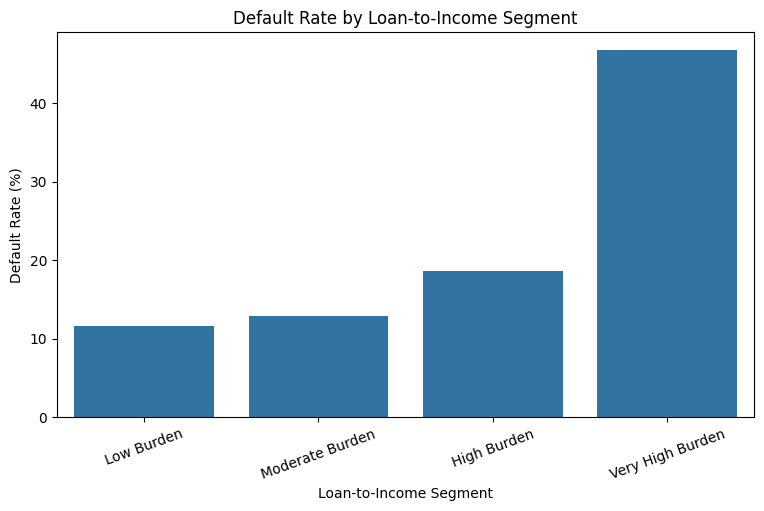

In [14]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=loan_income_risk.reset_index(),
    x="loan_income_segment",
    y="Default_Rate"
)
plt.title("Default Rate by Loan-to-Income Segment")
plt.xlabel("Loan-to-Income Segment")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

### 4.10 Interest Rate and Default Analysis

Interest rates are grouped into quartiles to examine whether observed default rates vary across different interest-rate ranges.

This analysis identifies relationships that can be investigated further during predictive modeling.

In [15]:
df["interest_rate_segment"] = pd.qcut(
    df["loan_int_rate"],
    q=4,
    labels=[
        "Low Interest",
        "Moderate Interest",
        "High Interest",
        "Very High Interest"
    ]
)
interest_risk = (
    df.groupby("interest_rate_segment", observed=True)
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)
interest_risk["Default_Rate"] = (interest_risk["Default_Rate"] * 100).round(2)
interest_risk

,Total_Loans,Defaults,Default_Rate
interest_rate_segment,,,
Low Interest,8410,810,9.63
Moderate Interest,9510,1629,17.13
High Interest,6401,1190,18.59
Very High Interest,8095,3460,42.74


### 4.11 Age-Based Risk Segmentation

Applicants are grouped into age bands to examine differences in observed default rates across borrower age groups.

In [16]:
age_bins = [0, 25, 35, 45, 55, 100]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["age_group"] = pd.cut(
    df["person_age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_risk = (
    df.groupby("age_group", observed=True)
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)

age_risk["Default_Rate"] = (
    age_risk["Default_Rate"] * 100
).round(2)

age_risk

,Total_Loans,Defaults,Default_Rate
age_group,,,
18-25,15245,3527,23.14
26-35,13711,2837,20.69
36-45,2809,581,20.68
46-55,512,112,21.88
56+,134,32,23.88


### 4.12 Borrower Risk Profile

A simple analytical risk profile is created using multiple observable characteristics.

The purpose is not to create a final credit-scoring model, but to identify combinations of characteristics that are associated with different observed default rates.

The indicators considered include:

- Loan grade
- Loan-to-income burden
- Previous default history
- Interest-rate segment

In [17]:
df["risk_indicator_count"] = (
    (df["loan_percent_income"] >= df["loan_percent_income"].quantile(0.75)).astype(int) +
    (df["loan_int_rate"] >= df["loan_int_rate"].quantile(0.75)).astype(int) +
    (df["cb_person_default_on_file"] == "Y").astype(int)
)

risk_profile = (
    df.groupby("risk_indicator_count")
      .agg(
          Total_Loans=("loan_status", "count"),
          Defaults=("loan_status", "sum"),
          Default_Rate=("loan_status", "mean")
      )
)

risk_profile["Default_Rate"] = (
    risk_profile["Default_Rate"] * 100
).round(2)

risk_profile

,Total_Loans,Defaults,Default_Rate
risk_indicator_count,,,
0,17142,1199,6.99
1,9413,3143,33.39
2,4610,1988,43.12
3,1251,759,60.67


### 4.13 Potential Anomaly Detection

Unusual combinations of financial characteristics are identified for further investigation.

These observations are labelled as potential anomalies rather than confirmed fraud or incorrect records.

The analysis focuses on unusually high income, unusually large loans, and high loan-to-income ratios.

In [18]:
income_threshold = df["person_income"].quantile(0.99)
loan_threshold = df["loan_amnt"].quantile(0.99)
ratio_threshold = df["loan_percent_income"].quantile(0.99)

df["potential_anomaly"] = (
    (df["person_income"] > income_threshold) |
    (df["loan_amnt"] > loan_threshold) |
    (df["loan_percent_income"] > ratio_threshold)
)

print("Potential anomaly records:", df["potential_anomaly"].sum())

Potential anomaly records: 842


### 4.14 Potential Anomaly Review

Potential anomaly records are summarized to understand their financial characteristics and loan outcomes.

These records require further validation before any conclusion about their correctness or risk status can be made.

In [19]:
anomaly_summary = df[df["potential_anomaly"]][[
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "loan_grade",
    "loan_status"
]]

anomaly_summary.head(20)

,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,loan_grade,loan_status
0,22,59000,35000,16.02,0.59,D,1
2,25,9600,5500,12.87,0.57,C,1
3,23,65500,35000,15.23,0.53,C,1
4,24,54400,35000,14.27,0.55,C,1
6,26,77100,35000,12.42,0.45,B,1
7,24,78956,35000,11.11,0.44,B,1
8,24,83000,35000,8.90,0.42,A,1
10,22,85000,35000,10.37,0.41,B,1
12,23,95000,35000,7.90,0.37,A,1
13,26,108160,35000,18.39,0.32,E,1


### 4.15 Risk Segment Summary

The major risk segments identified during the analysis are consolidated into a summary table.

This provides a structured view of the observed default patterns across borrower and loan characteristics.

In [20]:
risk_summary = pd.DataFrame({
    "Risk Dimension": [
        "Loan Grade",
        "Loan Intent",
        "Home Ownership",
        "Income Segment",
        "Loan-to-Income Segment",
        "Interest Rate Segment",
        "Age Group",
        "Previous Default History"
    ],
    "Highest Observed Default Segment": [
        grade_risk["Default_Rate"].idxmax(),
        intent_risk["Default_Rate"].idxmax(),
        home_risk["Default_Rate"].idxmax(),
        income_risk["Default_Rate"].idxmax(),
        loan_income_risk["Default_Rate"].idxmax(),
        interest_risk["Default_Rate"].idxmax(),
        age_risk["Default_Rate"].idxmax(),
        previous_default_risk["Default_Rate"].idxmax()
    ],
    "Default Rate (%)": [
        grade_risk["Default_Rate"].max(),
        intent_risk["Default_Rate"].max(),
        home_risk["Default_Rate"].max(),
        income_risk["Default_Rate"].max(),
        loan_income_risk["Default_Rate"].max(),
        interest_risk["Default_Rate"].max(),
        age_risk["Default_Rate"].max(),
        previous_default_risk["Default_Rate"].max()
    ]
})
risk_summary

,Risk Dimension,Highest Observed Default Segment,Default Rate (%)
0,Loan Grade,G,98.44
1,Loan Intent,DEBTCONSOLIDATION,28.68
2,Home Ownership,RENT,31.61
3,Income Segment,Low Income,39.75
4,Loan-to-Income Segment,Very High Burden,46.73
5,Interest Rate Segment,Very High Interest,42.74
6,Age Group,56+,23.88
7,Previous Default History,Y,37.87


### 4.16 Export Risk Analysis Dataset

The enriched dataset containing the analytical risk segments and potential anomaly indicator is exported for use in subsequent SQL analysis, machine learning, and Power BI development.

In [21]:
import os
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/credit_risk_analysis.csv",index=False)
print("Risk analysis dataset saved successfully.")

Risk analysis dataset saved successfully.


# Conclusion

- The overall loan default rate was established as the baseline measure for evaluating credit-risk patterns across different borrower and loan segments.
- Default rates were analyzed across loan grades, loan purposes, home ownership categories, income segments, age groups, interest-rate ranges, and previous default history.
- Loan-to-income segmentation was used to examine differences in observed default rates across varying levels of borrowing burden.
- Historical default information was analyzed as an important behavioral indicator for understanding borrower-level risk patterns.
- Multiple financial indicators were combined to create an exploratory risk profile for identifying segments with different observed default rates.
- Potential anomalies were identified using statistical thresholds across income, loan amount, and loan-to-income measures. These observations were flagged for further investigation rather than being classified as confirmed fraud or errors.
- The analysis revealed relationships and segment-level patterns that can be investigated further using statistical modeling and machine learning techniques.
- The resulting risk-analysis dataset provides a foundation for SQL-based risk reporting, predictive modeling, model explainability, and Power BI dashboard development.